# GANs — PyTorch Pipeline

## Model: Generative Adversarial Networks (GAN)
- **Dataset**: CIFAR-10 — 50,000 train / 10,000 test, 32x32x3 color images
- **Task**: Generate new images from random noise — first generative model in the project
- **Framework showcase**: Progressive GAN variants — training stability, loss design, conditional generation

## Evaluation Strategy
- **Primary metric**: FID (Frechet Inception Distance) — lower is better
- **Visual quality**: Generated image grids at training checkpoints
- **Training stability**: G/D loss curves, mode collapse detection

## Pipeline
1. Setup + load data
2. Vanilla GAN (MLP baseline)
3. DCGAN (convolutional architecture)
4. WGAN-GP (Wasserstein loss + gradient penalty)
5. Conditional GAN (class-conditional generation)
6. Evaluation & comparison (FID, visual grids, training curves)
7. Performance benchmarks
8. Save results

In [9]:
# Step 1: [1/9] Setup

"""
PyTorch GAN pipeline for CIFAR-10 image generation.
Progressive approach: Vanilla GAN → DCGAN → WGAN-GP → Conditional GAN.
Each variant addresses limitations exposed by the previous one.

GPU: RTX 4090 (24GB VRAM) — all training on GPU.
"""

import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import os
os.makedirs('results', exist_ok=True)

# Utils path
sys.path.insert(0, os.path.abspath('../..'))
from utils.data_loader import load_processed_data
from utils.performance import track_performance, track_inference, get_model_size
from utils.visualization import plot_generated_grid
from utils.gan_utils import compute_fid
from utils.results import save_results, add_result, print_comparison


# Constants 
RANDOM_STATE = 113
LATENT_DIM = 100        # Standard z-vector size for GANs
BATCH_SIZE = 128
IMAGE_SIZE = 32
IMAGE_CHANNELS = 3
LR = 0.0002             # DCGAN paper default
BETAS = (0.5, 0.999)    # DCGAN paper default

# Reproducibility
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_STATE)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load Data
X_train, X_test, y_train, y_test, meta = load_processed_data('gans')

print("=" * 60)
print("GAN Pipeline — PyTorch (CIFAR-10)")
print("=" * 60)
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"\nData shapes:")
print(f"  X_train: {X_train.shape} | range [{X_train.min():.3f}, {X_train.max():.3f}]")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape} | classes: {np.unique(y_train)}")
print(f"\nHyperparameters:")
print(f"  Latent dim:  {LATENT_DIM}")
print(f"  Batch size:  {BATCH_SIZE}")
print(f"  Learning rate: {LR}")
print(f"  Betas: {BETAS}")

# DataLoader
# Convert to channel-first (N, 3, 32, 32) for PyTorch
X_train_pt = np.transpose(X_train, (0, 3, 1, 2))  # (N, H, W, C) -> (N, C, H, W)
X_test_pt = np.transpose(X_test, (0, 3, 1, 2))

train_tensor = torch.tensor(X_train_pt, dtype=torch.float32)
label_tensor = torch.tensor(y_train, dtype=torch.long)
train_dataset = TensorDataset(train_tensor, label_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          drop_last=True)

print(f"\nDataLoader: {len(train_loader)} batches of {BATCH_SIZE}")
print(f"  Tensor shape per batch: ({BATCH_SIZE}, {IMAGE_CHANNELS}, {IMAGE_SIZE}, {IMAGE_SIZE})")

# Fixed noise for tracking generation quality over training
fixed_noise = torch.randn(64, LATENT_DIM, 1, 1, device=device)
print(f"\nFixed noise for tracking: {fixed_noise.shape}")

GAN Pipeline — PyTorch (CIFAR-10)
Device: cuda
GPU: NVIDIA GeForce RTX 4090
VRAM: 24.0 GB

Data shapes:
  X_train: (50000, 32, 32, 3) | range [-1.000, 1.000]
  X_test:  (10000, 32, 32, 3)
  y_train: (50000,) | classes: [0 1 2 3 4 5 6 7 8 9]

Hyperparameters:
  Latent dim:  100
  Batch size:  128
  Learning rate: 0.0002
  Betas: (0.5, 0.999)

DataLoader: 390 batches of 128
  Tensor shape per batch: (128, 3, 32, 32)

Fixed noise for tracking: torch.Size([64, 100, 1, 1])


[2/9] VANILLA GAN — MLP BASELINE
Generator params:     3,835,136
Discriminator params: 1,704,961
Training for 50 epochs...
  Epoch [  1/50] | D loss: 0.5405 | G loss: 3.3489
  Epoch [ 10/50] | D loss: 1.2723 | G loss: 1.1337
  Epoch [ 20/50] | D loss: 1.3278 | G loss: 0.9534
  Epoch [ 30/50] | D loss: 1.3559 | G loss: 0.8460
  Epoch [ 40/50] | D loss: 1.3674 | G loss: 0.8061
  Epoch [ 50/50] | D loss: 1.3663 | G loss: 0.7984


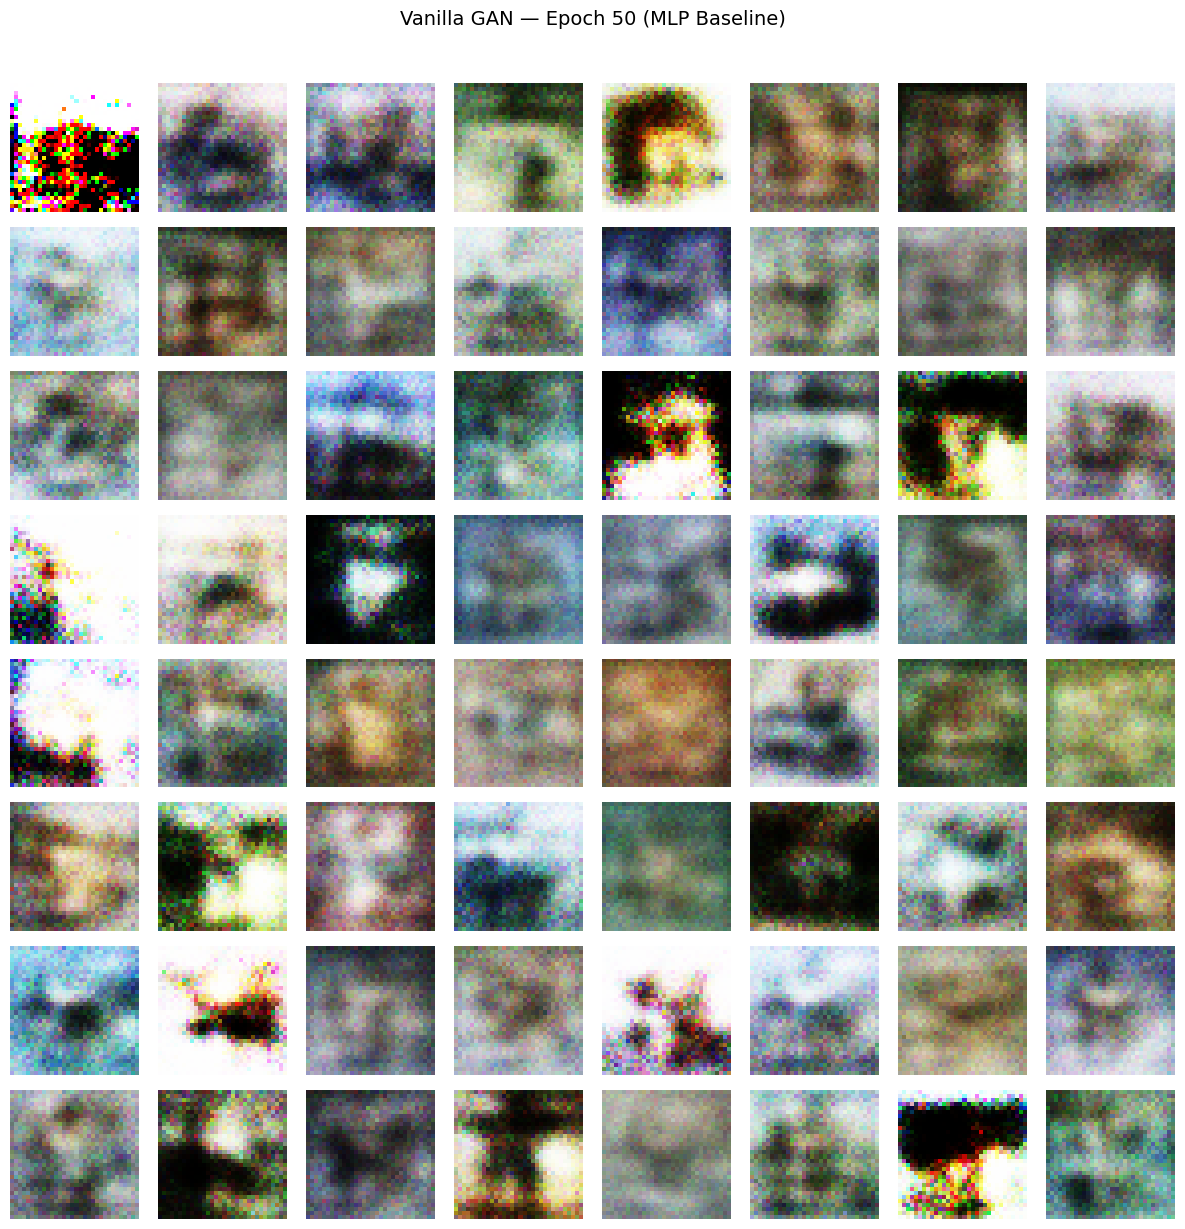

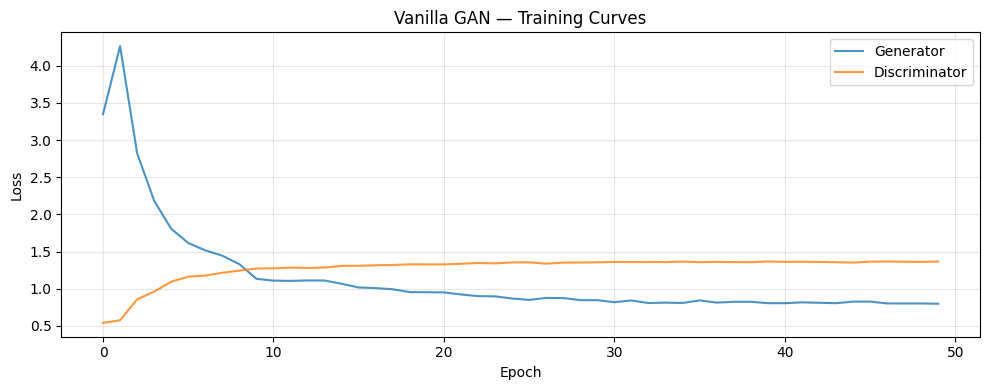

In [2]:
# Step 2: Vanilla GAN

"""
Simplest possible GAN: MLP Generator + MLP Discriminator with BCE loss.
Purpose: Establish baseline and expose limitations (blurry output, mode
collapse, training instability) that motivate convolutional architectures.
"""

print("=" * 60)
print("[2/8] VANILLA GAN — MLP BASELINE")
print("=" * 60)

# Architectures

class VanillaGenerator(nn.Module):
    # MLP generator: z(100) -> 3072 pixels -> reshape to image
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(True),
            nn.Linear(1024, IMAGE_CHANNELS * IMAGE_SIZE * IMAGE_SIZE),
            nn.Tanh()  # Output [-1, 1] to match data normalization
        )

    def forward(self, z):
        # z comes as (N, 100, 1, 1) from fixed_noise — flatten it
        z = z.view(z.size(0), -1)
        out = self.net(z)
        return out.view(-1, IMAGE_CHANNELS, IMAGE_SIZE, IMAGE_SIZE)


class VanillaDiscriminator(nn.Module):
    # MLP discriminator: flatten image -> binary real/fake
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(IMAGE_CHANNELS * IMAGE_SIZE * IMAGE_SIZE, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


# Training
VANILLA_EPOCHS = 50

G_vanilla = VanillaGenerator().to(device)
D_vanilla = VanillaDiscriminator().to(device)

opt_G = optim.Adam(G_vanilla.parameters(), lr=LR, betas=BETAS)
opt_D = optim.Adam(D_vanilla.parameters(), lr=LR, betas=BETAS)
criterion = nn.BCELoss()

# Labels for real/fake
real_label = 1.0
fake_label = 0.0

g_losses_vanilla = []
d_losses_vanilla = []

print(f"Generator params:     {sum(p.numel() for p in G_vanilla.parameters()):,}")
print(f"Discriminator params: {sum(p.numel() for p in D_vanilla.parameters()):,}")
print(f"Training for {VANILLA_EPOCHS} epochs...")

for epoch in range(VANILLA_EPOCHS):
    g_loss_epoch = 0.0
    d_loss_epoch = 0.0

    for real_imgs, _ in train_loader:
        batch_size = real_imgs.size(0)
        real_imgs = real_imgs.to(device)

        # --- Train Discriminator ---
        # Real images
        labels_real = torch.full((batch_size, 1), real_label, device=device)
        output_real = D_vanilla(real_imgs)
        loss_real = criterion(output_real, labels_real)

        # Fake images
        noise = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
        fake_imgs = G_vanilla(noise).detach()  # detach to avoid training G
        labels_fake = torch.full((batch_size, 1), fake_label, device=device)
        output_fake = D_vanilla(fake_imgs)
        loss_fake = criterion(output_fake, labels_fake)

        loss_D = loss_real + loss_fake
        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # --- Train Generator ---
        noise = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
        fake_imgs = G_vanilla(noise)
        output = D_vanilla(fake_imgs)
        # G wants D to think fakes are real
        loss_G = criterion(output, labels_real)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        g_loss_epoch += loss_G.item()
        d_loss_epoch += loss_D.item()

    g_losses_vanilla.append(g_loss_epoch / len(train_loader))
    d_losses_vanilla.append(d_loss_epoch / len(train_loader))

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"  Epoch [{epoch+1:>3}/{VANILLA_EPOCHS}] | "
              f"D loss: {d_losses_vanilla[-1]:.4f} | "
              f"G loss: {g_losses_vanilla[-1]:.4f}")

# Generate & Display
G_vanilla.eval()
with torch.no_grad():
    fake_samples = G_vanilla(fixed_noise).cpu().numpy()
G_vanilla.train()

plot_generated_grid(fake_samples, nrow=8,
                    title='Vanilla GAN — Epoch 50 (MLP Baseline)',
                    save_path='results/vanilla_gan_samples.png')

# Training curves
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(g_losses_vanilla, label='Generator', alpha=0.8)
ax.plot(d_losses_vanilla, label='Discriminator', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Vanilla GAN — Training Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/vanilla_gan_curves.png', dpi=150, bbox_inches='tight')
plt.show()

[3/8] DCGAN — CONVOLUTIONAL ARCHITECTURE
Generator params:     1,068,928
Discriminator params: 663,296
Training for 100 epochs...
  Epoch [  1/100] | D loss: 0.4539 | G loss: 4.8211
  Epoch [ 20/100] | D loss: 0.8280 | G loss: 1.7805
  Epoch [ 40/100] | D loss: 0.6407 | G loss: 2.0079
  Epoch [ 60/100] | D loss: 0.5148 | G loss: 2.4736
  Epoch [ 80/100] | D loss: 0.4272 | G loss: 2.8426
  Epoch [100/100] | D loss: 0.4222 | G loss: 3.1680


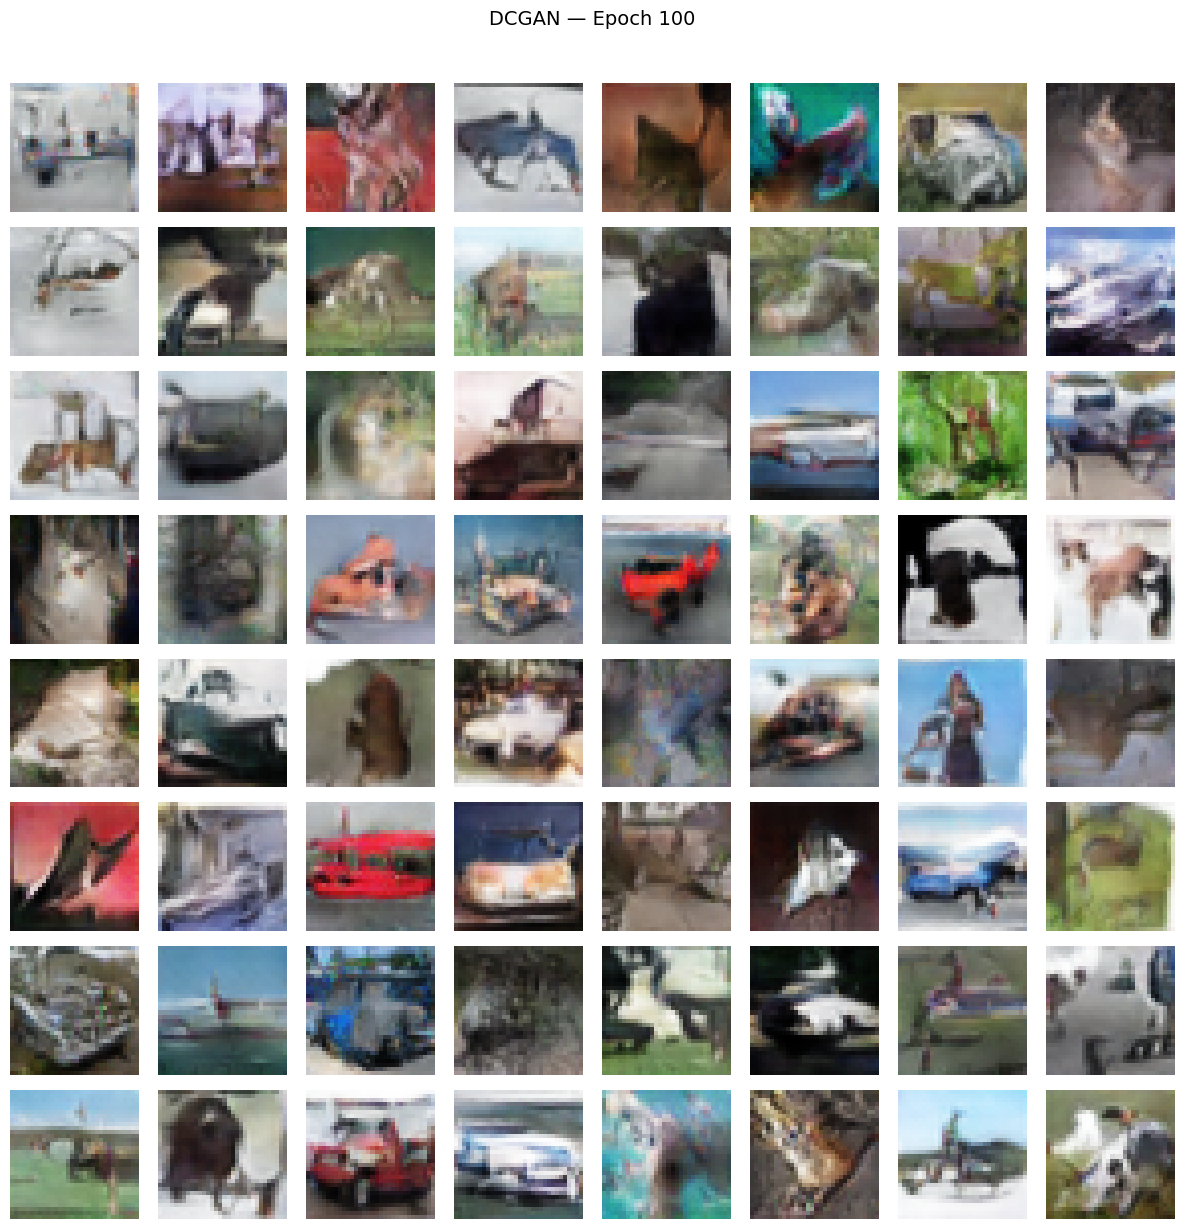

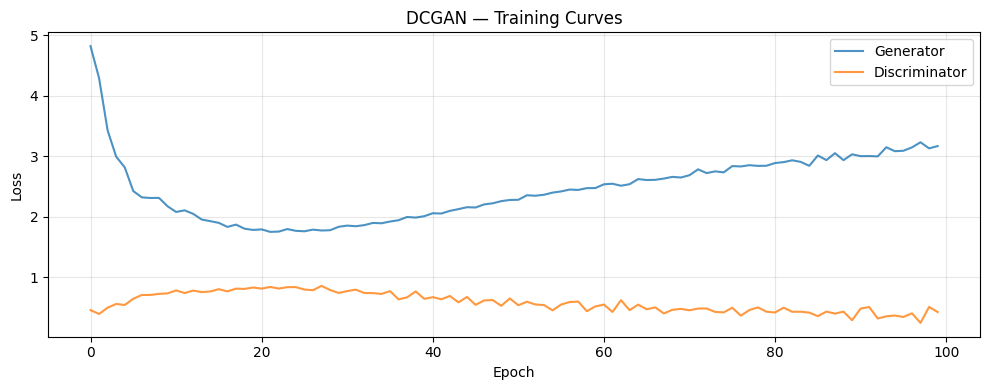

In [3]:
# Step 3: DCGAN (Deep Convolutional GAN)

"""
Replace MLP with convolutional architecture. DCGAN paper guidelines:
- Generator: ConvTranspose2d (fractional-strided convolutions) for upsampling
- Discriminator: strided Conv2d for downsampling
- BatchNorm in both (except D input layer and G output layer)
- ReLU in G, LeakyReLU(0.2) in D
- Weight init: Normal(0, 0.02)

Expected: Major quality jump — conv layers exploit spatial locality that
MLP completely misses. The blurry blobs should become recognizable objects.
"""

print("=" * 60)
print("[3/8] DCGAN — CONVOLUTIONAL ARCHITECTURE")
print("=" * 60)

# Weight Initialization (DCGAN paper)
def weights_init(m):
    # DCGAN weight init: Conv/ConvT -> N(0, 0.02), BN -> N(1, 0.02).
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


# Architectures

class DCGenerator(nn.Module):
    """
    DCGAN Generator: z(100,1,1) -> (3,32,32) via transposed convolutions.
    4x4 -> 8x8 -> 16x16 -> 32x32
    """
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.main = nn.Sequential(
            # z(100,1,1) -> (256, 4, 4)
            nn.ConvTranspose2d(latent_dim, 256, 4, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # (256, 4, 4) -> (128, 8, 8)
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # (128, 8, 8) -> (64, 16, 16)
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # (64, 16, 16) -> (3, 32, 32)
            nn.ConvTranspose2d(64, IMAGE_CHANNELS, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.main(z)


class DCDiscriminator(nn.Module):
    """
    DCGAN Discriminator: (3,32,32) -> scalar via strided convolutions.
    32x32 -> 16x16 -> 8x8 -> 4x4 -> 1x1
    """
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # (3, 32, 32) -> (64, 16, 16) — no BN on first layer
            nn.Conv2d(IMAGE_CHANNELS, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # (64, 16, 16) -> (128, 8, 8)
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # (128, 8, 8) -> (256, 4, 4)
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            # (256, 4, 4) -> (1, 1, 1)
            nn.Conv2d(256, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x).view(-1, 1)


# Training
DCGAN_EPOCHS = 100

G_dc = DCGenerator().to(device)
D_dc = DCDiscriminator().to(device)
G_dc.apply(weights_init)
D_dc.apply(weights_init)

opt_G = optim.Adam(G_dc.parameters(), lr=LR, betas=BETAS)
opt_D = optim.Adam(D_dc.parameters(), lr=LR, betas=BETAS)
criterion = nn.BCELoss()

g_losses_dc = []
d_losses_dc = []

print(f"Generator params:     {sum(p.numel() for p in G_dc.parameters()):,}")
print(f"Discriminator params: {sum(p.numel() for p in D_dc.parameters()):,}")
print(f"Training for {DCGAN_EPOCHS} epochs...")

for epoch in range(DCGAN_EPOCHS):
    g_loss_epoch = 0.0
    d_loss_epoch = 0.0

    for real_imgs, _ in train_loader:
        batch_size = real_imgs.size(0)
        real_imgs = real_imgs.to(device)

        # --- Train Discriminator ---
        labels_real = torch.full((batch_size, 1), real_label, device=device)
        output_real = D_dc(real_imgs)
        loss_real = criterion(output_real, labels_real)

        noise = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
        fake_imgs = G_dc(noise).detach()
        labels_fake = torch.full((batch_size, 1), fake_label, device=device)
        output_fake = D_dc(fake_imgs)
        loss_fake = criterion(output_fake, labels_fake)

        loss_D = loss_real + loss_fake
        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # --- Train Generator ---
        noise = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
        fake_imgs = G_dc(noise)
        output = D_dc(fake_imgs)
        loss_G = criterion(output, labels_real)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        g_loss_epoch += loss_G.item()
        d_loss_epoch += loss_D.item()

    g_losses_dc.append(g_loss_epoch / len(train_loader))
    d_losses_dc.append(d_loss_epoch / len(train_loader))

    if (epoch + 1) % 20 == 0 or epoch == 0:
        print(f"  Epoch [{epoch+1:>3}/{DCGAN_EPOCHS}] | "
              f"D loss: {d_losses_dc[-1]:.4f} | "
              f"G loss: {g_losses_dc[-1]:.4f}")

# Generate & Display
G_dc.eval()
with torch.no_grad():
    fake_samples_dc = G_dc(fixed_noise).cpu().numpy()
G_dc.train()

plot_generated_grid(fake_samples_dc, nrow=8,
                    title='DCGAN — Epoch 100',
                    save_path='results/dcgan_samples.png')

# Training curves
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(g_losses_dc, label='Generator', alpha=0.8)
ax.plot(d_losses_dc, label='Discriminator', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('DCGAN — Training Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/dcgan_curves.png', dpi=150, bbox_inches='tight')
plt.show()

[4/8] WGAN-GP — WASSERSTEIN LOSS + GRADIENT PENALTY
Generator params:     1,068,928
Critic params:        687,104
Training for 100 epochs (n_critic=5, lambda_gp=10.0)...
  Epoch [  1/100] | D loss: -8.3621 | G loss: 11.3599 | W-dist: 11.5422
  Epoch [ 20/100] | D loss: -2.3270 | G loss: 19.4366 | W-dist: 2.9039
  Epoch [ 40/100] | D loss: -1.6708 | G loss: 12.7231 | W-dist: 2.1531
  Epoch [ 60/100] | D loss: -1.3241 | G loss: 6.8718 | W-dist: 1.7651
  Epoch [ 80/100] | D loss: -1.1072 | G loss: 6.6013 | W-dist: 1.5216
  Epoch [100/100] | D loss: -1.0539 | G loss: 8.5018 | W-dist: 1.4193


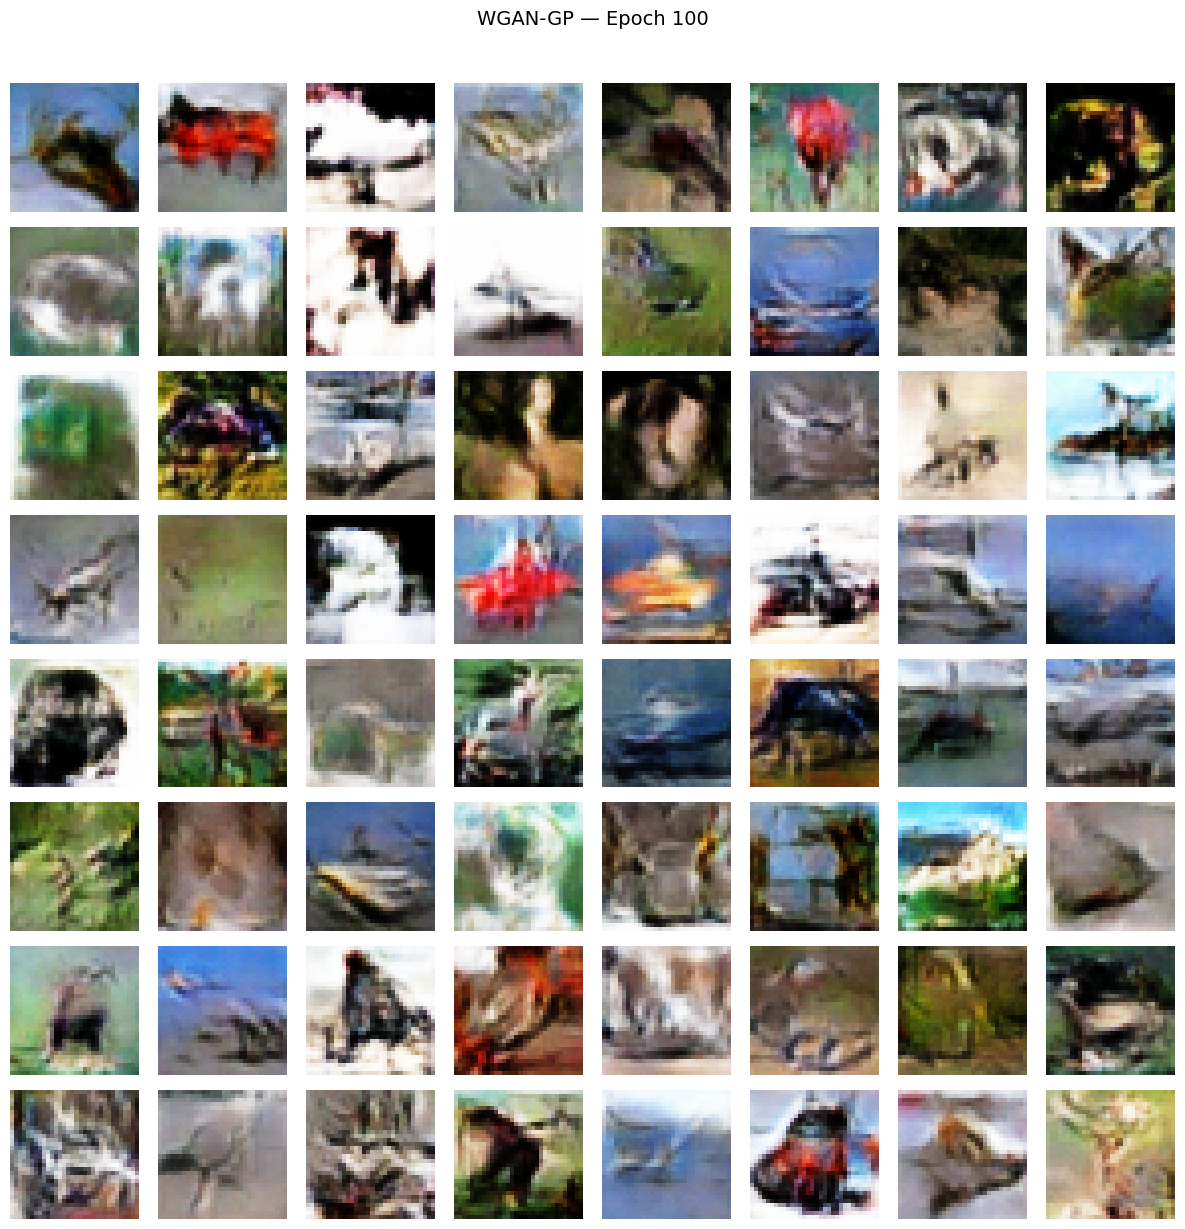

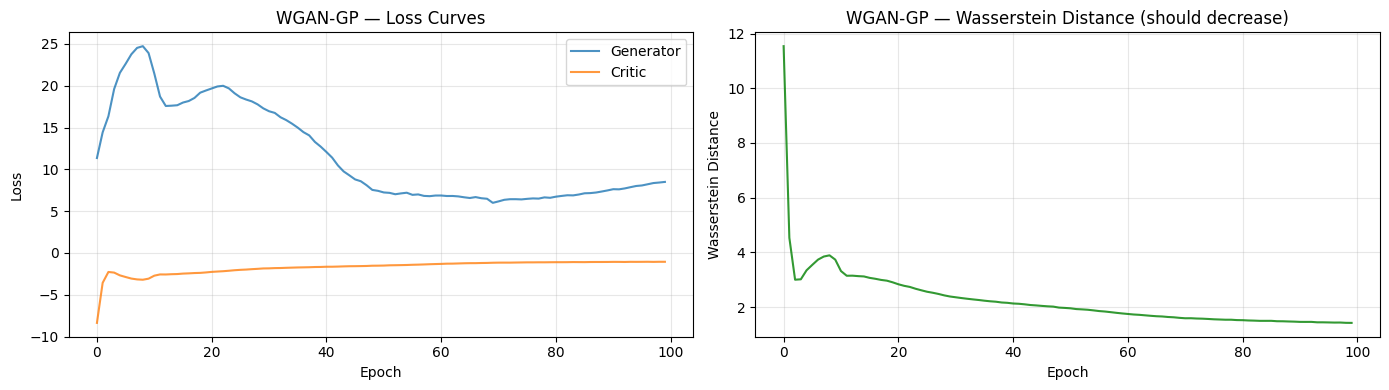


Observations (drives next cell):
  - Quality vs DCGAN? Better/worse/same?
  - W-distance trend? Smoothly decreasing = good
  - Training stability? No D-winning collapse?


In [ ]:
# Step 4: WGAN-GP (Wasserstein GAN with Gradient Penalty)

"""
Address DCGAN's training instability: D winning → G gradient vanishing.
Key changes from DCGAN:
  1. Wasserstein loss replaces BCE — meaningful distance metric
  2. Gradient penalty replaces weight clipping — stable training
  3. Critic (no sigmoid) trained 5x per G step — stronger signal
  4. No BN in Critic (interferes with gradient penalty)
  5. Different Adam betas: (0.0, 0.9) per WGAN-GP paper

Expected: Smoothly decreasing Wasserstein distance that correlates
with visual quality. More stable training, no D-winning collapse.
"""

print("=" * 60)
print("[4/8] WGAN-GP — WASSERSTEIN LOSS + GRADIENT PENALTY")
print("=" * 60)

# Architectures (same conv structure, different normalization)

class WGANGenerator(nn.Module):
    # Same conv architecture as DCGAN generator
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 256, 4, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, IMAGE_CHANNELS, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.main(z)


class WGANCritic(nn.Module):
    """
    Critic (not discriminator) — outputs raw score, no sigmoid.
    Uses LayerNorm instead of BatchNorm (BN interferes with GP).
    """
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            # (3, 32, 32) -> (64, 16, 16) — no normalization on first layer
            nn.Conv2d(IMAGE_CHANNELS, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # (64, 16, 16) -> (128, 8, 8)
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.LayerNorm([128, 8, 8]),
            nn.LeakyReLU(0.2, inplace=True),
            # (128, 8, 8) -> (256, 4, 4)
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.LayerNorm([256, 4, 4]),
            nn.LeakyReLU(0.2, inplace=True),
            # (256, 4, 4) -> (1, 1, 1) — raw score, no sigmoid
            nn.Conv2d(256, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x):
        return self.main(x).view(-1)


def compute_gradient_penalty(critic, real, fake, device):
    """
    WGAN-GP gradient penalty: penalize critic gradients deviating from norm 1.
    Interpolates between real and fake samples, computes critic gradient
    w.r.t. interpolated input, penalizes ||grad||_2 != 1.

    Args:
        critic: WGANCritic model.
        real: Real image batch (N, C, H, W).
        fake: Fake image batch (N, C, H, W).
        device: torch device.

    Returns:
        gradient_penalty: scalar tensor.
    """
    batch_size = real.size(0)
    # Random interpolation factor per sample
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)
    # Interpolate between real and fake
    interpolated = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    # Critic score on interpolated
    critic_score = critic(interpolated)
    # Compute gradients w.r.t. interpolated input
    gradients = torch.autograd.grad(
        outputs=critic_score,
        inputs=interpolated,
        grad_outputs=torch.ones_like(critic_score),
        create_graph=True,
        retain_graph=True
    )[0]
    # Flatten gradients and compute L2 norm per sample
    gradients = gradients.view(batch_size, -1)
    gradient_norm = gradients.norm(2, dim=1)
    # Penalize deviation from 1
    penalty = ((gradient_norm - 1.0) ** 2).mean()
    return penalty


# Training
WGAN_EPOCHS = 100
N_CRITIC = 5          # Train critic 5x per generator step
LAMBDA_GP = 10.0      # Gradient penalty weight
LR_WGAN = 0.0001      # Lower LR per WGAN-GP paper
BETAS_WGAN = (0.0, 0.9)

G_wgan = WGANGenerator().to(device)
D_wgan = WGANCritic().to(device)
G_wgan.apply(weights_init)
D_wgan.apply(weights_init)

opt_G = optim.Adam(G_wgan.parameters(), lr=LR_WGAN, betas=BETAS_WGAN)
opt_D = optim.Adam(D_wgan.parameters(), lr=LR_WGAN, betas=BETAS_WGAN)

g_losses_wgan = []
d_losses_wgan = []
w_distances = []  # Wasserstein distance: E[C(real)] - E[C(fake)]

print(f"Generator params:     {sum(p.numel() for p in G_wgan.parameters()):,}")
print(f"Critic params:        {sum(p.numel() for p in D_wgan.parameters()):,}")
print(f"Training for {WGAN_EPOCHS} epochs (n_critic={N_CRITIC}, lambda_gp={LAMBDA_GP})...")

for epoch in range(WGAN_EPOCHS):
    g_loss_epoch = 0.0
    d_loss_epoch = 0.0
    w_dist_epoch = 0.0
    g_steps = 0

    for batch_idx, (real_imgs, _) in enumerate(train_loader):
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        # Train Critic (N_CRITIC steps)
        noise = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
        fake_imgs = G_wgan(noise).detach()

        critic_real = D_wgan(real_imgs).mean()
        critic_fake = D_wgan(fake_imgs).mean()
        gp = compute_gradient_penalty(D_wgan, real_imgs, fake_imgs, device)

        # Critic wants to MAXIMIZE (real - fake), so we MINIMIZE -(real - fake)
        loss_D = critic_fake - critic_real + LAMBDA_GP * gp

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        d_loss_epoch += loss_D.item()
        w_dist_epoch += (critic_real - critic_fake).item()

        # Train Generator (every N_CRITIC steps)
        if (batch_idx + 1) % N_CRITIC == 0:
            noise = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
            fake_imgs = G_wgan(noise)
            # G wants to MAXIMIZE critic score on fakes
            loss_G = -D_wgan(fake_imgs).mean()

            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

            g_loss_epoch += loss_G.item()
            g_steps += 1

    g_losses_wgan.append(g_loss_epoch / max(g_steps, 1))
    d_losses_wgan.append(d_loss_epoch / len(train_loader))
    w_distances.append(w_dist_epoch / len(train_loader))

    if (epoch + 1) % 20 == 0 or epoch == 0:
        print(f"  Epoch [{epoch+1:>3}/{WGAN_EPOCHS}] | "
              f"D loss: {d_losses_wgan[-1]:.4f} | "
              f"G loss: {g_losses_wgan[-1]:.4f} | "
              f"W-dist: {w_distances[-1]:.4f}")

# Generate & Display
G_wgan.eval()
with torch.no_grad():
    fake_samples_wgan = G_wgan(fixed_noise).cpu().numpy()
G_wgan.train()

plot_generated_grid(fake_samples_wgan, nrow=8,
                    title='WGAN-GP — Epoch 100',
                    save_path='results/wgan_gp_samples.png')

# Training curves with Wasserstein distance
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(g_losses_wgan, label='Generator', alpha=0.8)
axes[0].plot(d_losses_wgan, label='Critic', alpha=0.8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('WGAN-GP — Loss Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(w_distances, color='green', alpha=0.8)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Wasserstein Distance')
axes[1].set_title('WGAN-GP — Wasserstein Distance (should decrease)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/wgan_gp_curves.png', dpi=150, bbox_inches='tight')
plt.show()

[5/8] CONDITIONAL GAN — CLASS-CONDITIONAL GENERATION
Generator params:     1,479,528
Discriminator params: 674,560
Training for 100 epochs...
  Epoch [  1/100] | D loss: 0.6232 | G loss: 3.2332
  Epoch [ 20/100] | D loss: 0.5285 | G loss: 3.0699
  Epoch [ 40/100] | D loss: 0.4366 | G loss: 3.3822
  Epoch [ 60/100] | D loss: 0.3789 | G loss: 3.8022
  Epoch [ 80/100] | D loss: 0.3302 | G loss: 4.2353
  Epoch [100/100] | D loss: 0.2963 | G loss: 4.2814


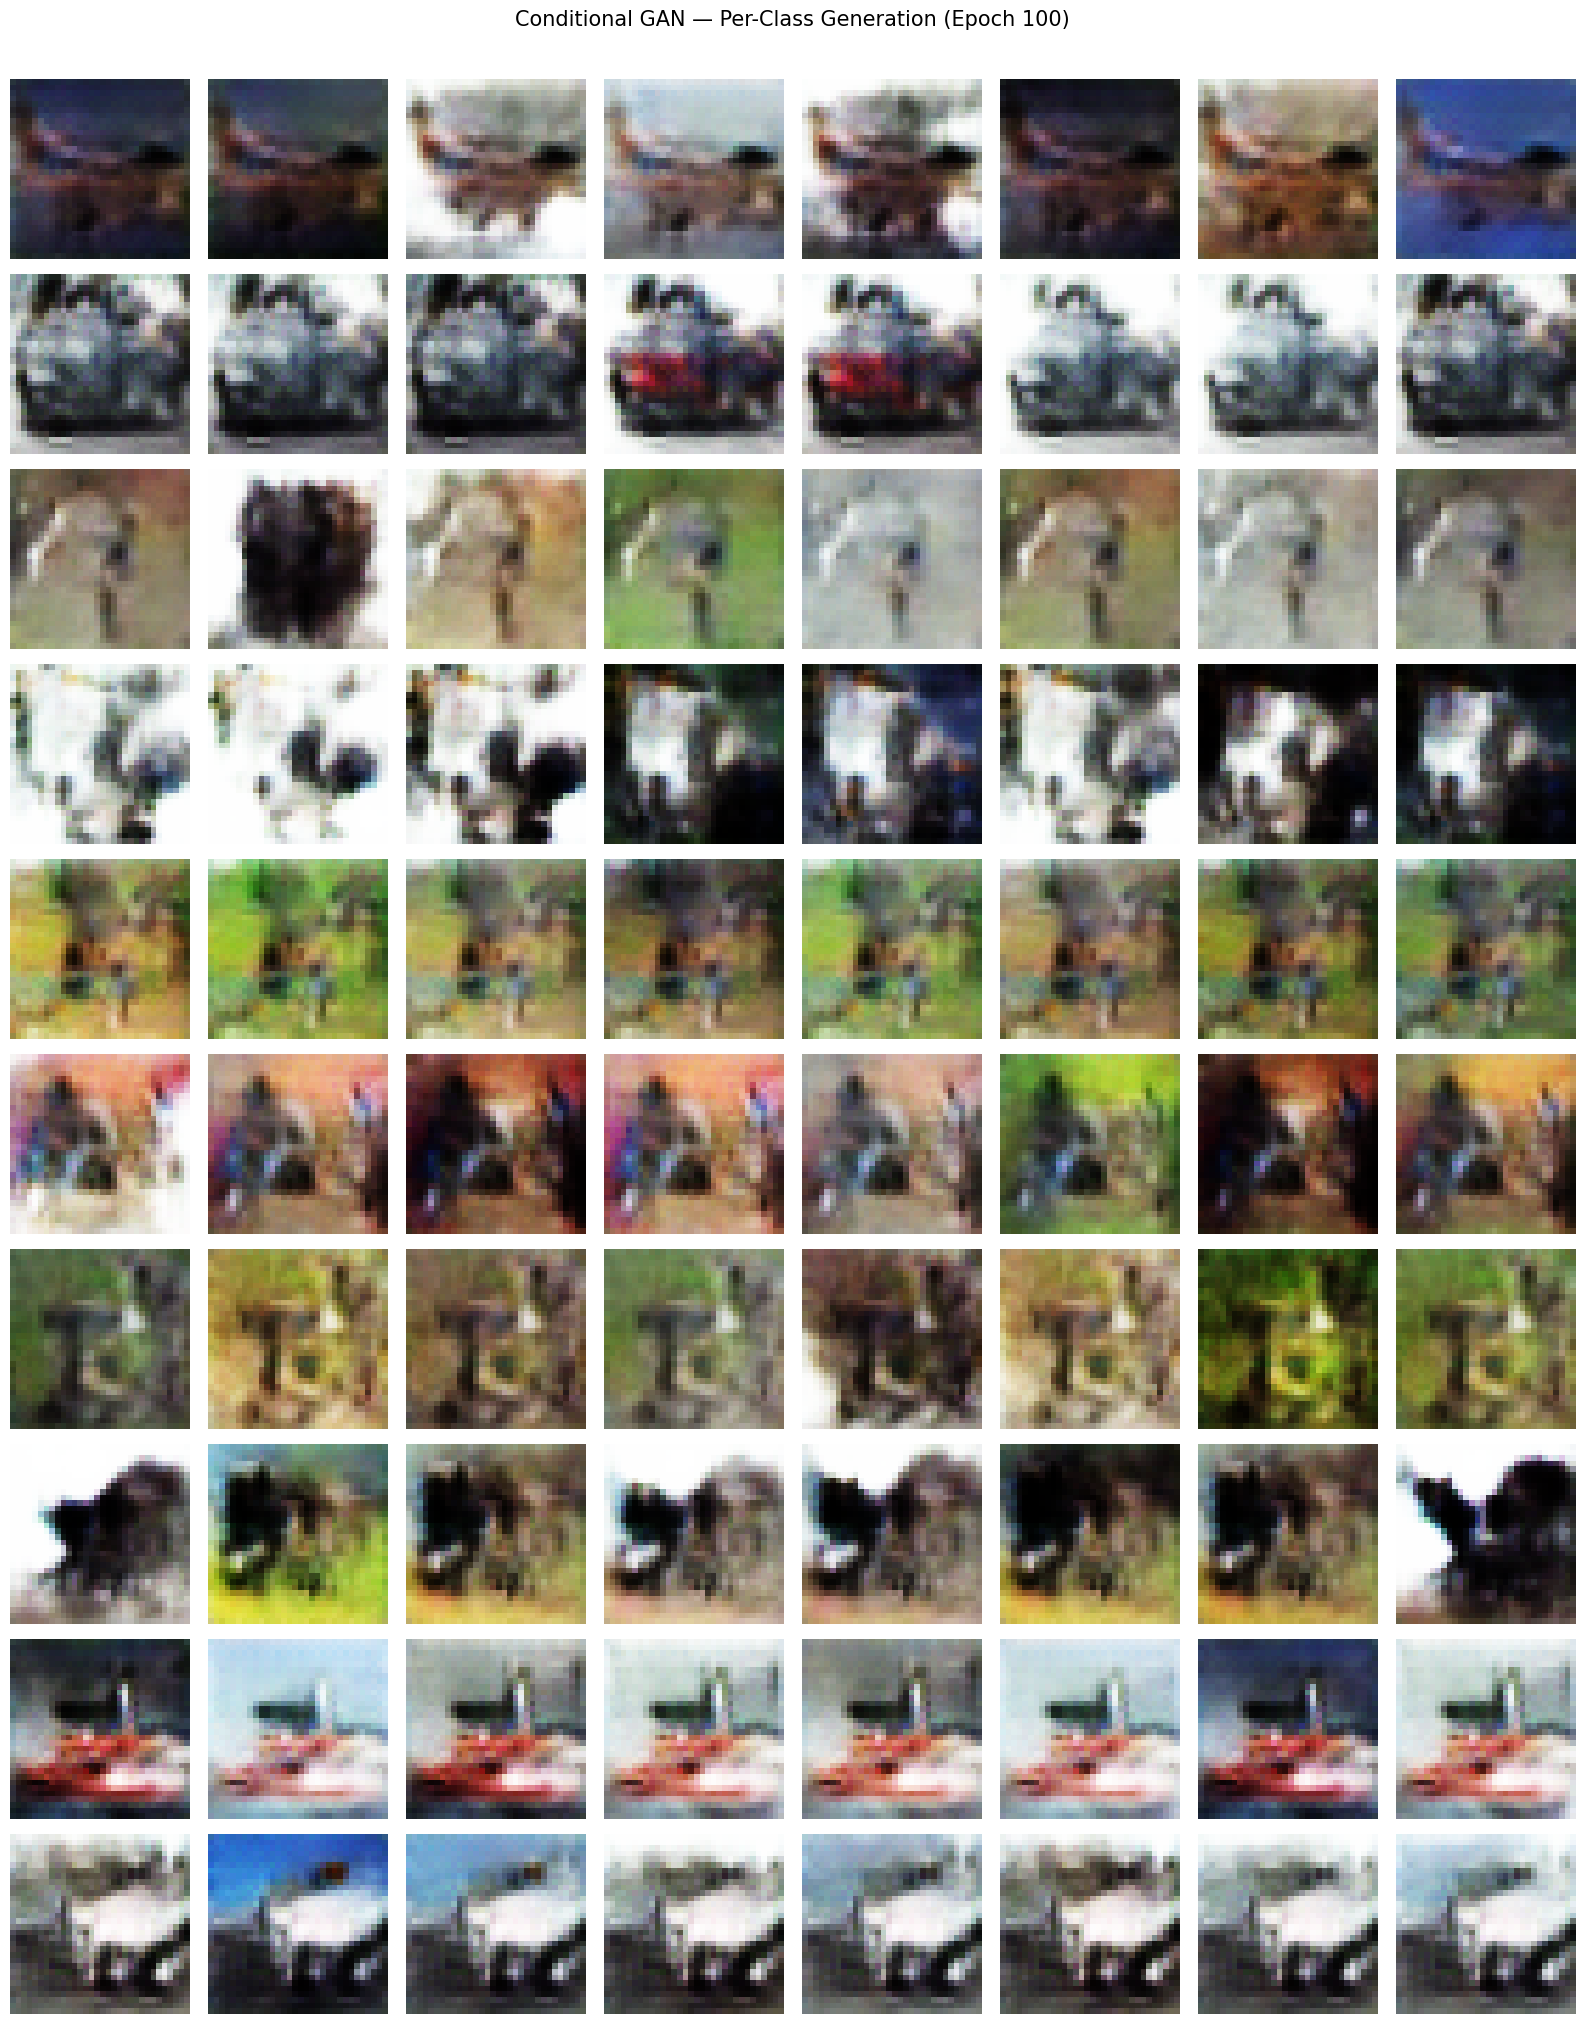

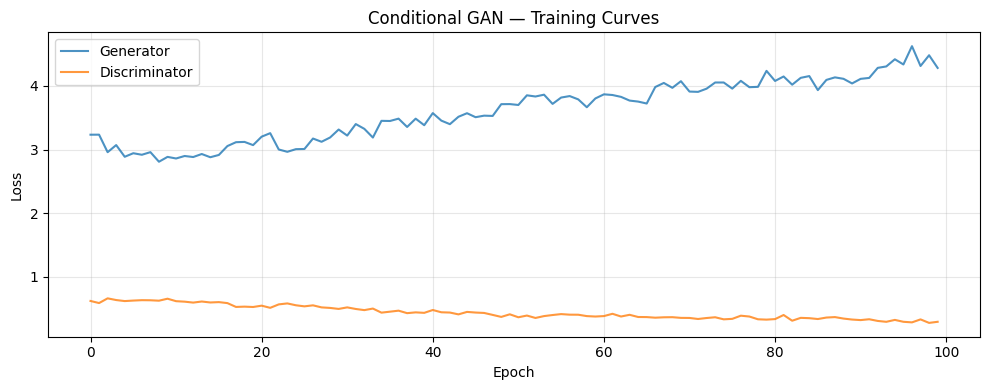


Observations:
  - Can it generate class-specific images?
  - Which classes are easiest/hardest to generate?
  - Per-class diversity — mode collapse within any class?


In [ ]:
# Step 5: Conditional GAN (cGAN)

"""
Add class-conditional generation to the best base architecture.
DCGAN had slightly crisper images, WGAN-GP had more stable training.
Using DCGAN's BCE approach with class embeddings for simplicity —
the conditional mechanism is the showcase here, not the loss function.

Key changes:
  - Generator: Embed class label, concatenate with z before first layer
  - Discriminator: Embed class label, project to spatial dims, concat as
    extra channel (input becomes 4-channel: 3 RGB + 1 label map)
  - Both G and D receive the class label during training

Expected: Generate specific CIFAR-10 classes on demand.
"""

print("=" * 60)
print("[5/8] CONDITIONAL GAN — CLASS-CONDITIONAL GENERATION")
print("=" * 60)

N_CLASSES = 10

# Architectures

class ConditionalGenerator(nn.Module):
    """
    cGAN Generator: concatenate class embedding with noise z.
    label -> Embedding(10, LATENT_DIM) -> concat with z -> ConvT pipeline.
    Input: z(LATENT_DIM,1,1) + label -> (3,32,32)
    """
    def __init__(self, latent_dim=LATENT_DIM, n_classes=N_CLASSES):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, latent_dim)
        # Input is z + embedding = 2 * latent_dim channels
        self.main = nn.Sequential(
            nn.ConvTranspose2d(latent_dim * 2, 256, 4, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, IMAGE_CHANNELS, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z, labels):
        # z: (N, LATENT_DIM, 1, 1), labels: (N,)
        emb = self.label_emb(labels).unsqueeze(2).unsqueeze(3)  # (N, LATENT_DIM, 1, 1)
        x = torch.cat([z, emb], dim=1)  # (N, 2*LATENT_DIM, 1, 1)
        return self.main(x)


class ConditionalDiscriminator(nn.Module):
    """
    cGAN Discriminator: concat class label as extra spatial channel.
    label -> Embedding(10, 32*32) -> reshape to (1,32,32) -> concat with image.
    Input: (4, 32, 32) -> scalar
    """
    def __init__(self, n_classes=N_CLASSES):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, IMAGE_SIZE * IMAGE_SIZE)
        # 4 input channels: 3 RGB + 1 label map
        self.main = nn.Sequential(
            nn.Conv2d(IMAGE_CHANNELS + 1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x, labels):
        # labels: (N,) -> spatial map (N, 1, 32, 32)
        emb = self.label_emb(labels)  # (N, 32*32)
        emb = emb.view(-1, 1, IMAGE_SIZE, IMAGE_SIZE)  # (N, 1, 32, 32)
        x = torch.cat([x, emb], dim=1)  # (N, 4, 32, 32)
        return self.main(x).view(-1, 1)


# Training
CGAN_EPOCHS = 100

G_cgan = ConditionalGenerator().to(device)
D_cgan = ConditionalDiscriminator().to(device)
G_cgan.apply(weights_init)
D_cgan.apply(weights_init)

opt_G = optim.Adam(G_cgan.parameters(), lr=LR, betas=BETAS)
opt_D = optim.Adam(D_cgan.parameters(), lr=LR, betas=BETAS)
criterion = nn.BCELoss()

g_losses_cgan = []
d_losses_cgan = []

print(f"Generator params:     {sum(p.numel() for p in G_cgan.parameters()):,}")
print(f"Discriminator params: {sum(p.numel() for p in D_cgan.parameters()):,}")
print(f"Training for {CGAN_EPOCHS} epochs...")

for epoch in range(CGAN_EPOCHS):
    g_loss_epoch = 0.0
    d_loss_epoch = 0.0

    for real_imgs, real_labels in train_loader:
        batch_size = real_imgs.size(0)
        real_imgs = real_imgs.to(device)
        real_labels = real_labels.to(device)

        # --- Train Discriminator ---
        labels_real = torch.full((batch_size, 1), real_label, device=device)
        output_real = D_cgan(real_imgs, real_labels)
        loss_real = criterion(output_real, labels_real)

        noise = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
        # Use real labels for fakes too — D must learn class-conditional discrimination
        fake_imgs = G_cgan(noise, real_labels).detach()
        labels_fake = torch.full((batch_size, 1), fake_label, device=device)
        output_fake = D_cgan(fake_imgs, real_labels)
        loss_fake = criterion(output_fake, labels_fake)

        loss_D = loss_real + loss_fake
        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # --- Train Generator ---
        noise = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
        fake_imgs = G_cgan(noise, real_labels)
        output = D_cgan(fake_imgs, real_labels)
        loss_G = criterion(output, labels_real)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        g_loss_epoch += loss_G.item()
        d_loss_epoch += loss_D.item()

    g_losses_cgan.append(g_loss_epoch / len(train_loader))
    d_losses_cgan.append(d_loss_epoch / len(train_loader))

    if (epoch + 1) % 20 == 0 or epoch == 0:
        print(f"  Epoch [{epoch+1:>3}/{CGAN_EPOCHS}] | "
              f"D loss: {d_losses_cgan[-1]:.4f} | "
              f"G loss: {g_losses_cgan[-1]:.4f}")

# Generate Per-Class Samples
G_cgan.eval()
CLASS_NAMES = meta['class_names']

# Generate 8 images per class (10 classes x 8 = 80 images)
all_class_images = []
with torch.no_grad():
    for class_idx in range(N_CLASSES):
        noise = torch.randn(8, LATENT_DIM, 1, 1, device=device)
        labels = torch.full((8,), class_idx, dtype=torch.long, device=device)
        generated = G_cgan(noise, labels).cpu().numpy()
        all_class_images.append(generated)

# Display as 10 rows x 8 cols grid
all_images = np.concatenate(all_class_images, axis=0)  # (80, 3, 32, 32)

fig, axes = plt.subplots(10, 8, figsize=(16, 20))
for row in range(10):
    for col in range(8):
        idx = row * 8 + col
        img = all_images[idx]
        # Channel-first -> channel-last, rescale [-1,1] -> [0,1]
        img = np.transpose(img, (1, 2, 0))
        img = (img + 1.0) / 2.0
        img = np.clip(img, 0, 1)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(CLASS_NAMES[row], fontsize=11,
                             rotation=0, labelpad=70, va='center')

fig.suptitle('Conditional GAN — Per-Class Generation (Epoch 100)', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('results/cgan_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
G_cgan.train()

# Training curves
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(g_losses_cgan, label='Generator', alpha=0.8)
ax.plot(d_losses_cgan, label='Discriminator', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Conditional GAN — Training Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/cgan_curves.png', dpi=150, bbox_inches='tight')
plt.show()

[6/8] EVALUATION & COMPARISON

Generating 10K images per variant for FID...

1/4: Vanilla GAN...
2/4: DCGAN...
3/4: WGAN-GP...
4/4: Conditional GAN...

Computing FID scores (InceptionV3 features)...


c:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to C:\Users\Max/.cache\torch\hub\checkpoints\inception_v3_google-0cc3c7bd.pth
100.0%


    Extracting features from 10000 real images...
    Extracting features from 10000 fake images...
  Vanilla GAN FID: 261.47
    Extracting features from 10000 real images...
    Extracting features from 10000 fake images...
  DCGAN FID:       30.57
    Extracting features from 10000 real images...
    Extracting features from 10000 fake images...
  WGAN-GP FID:     55.35
    Extracting features from 10000 real images...
    Extracting features from 10000 fake images...
  cGAN FID:        147.90

CROSS-VARIANT COMPARISON
Variant                     FID     G Params     Training
--------------------------------------------------------
Vanilla GAN              261.47    3,835,136    BCE, 50ep
DCGAN                     30.57    1,068,928   BCE, 100ep
WGAN-GP                   55.35    1,068,928  Wass, 100ep
Conditional GAN          147.90    1,479,528   BCE, 100ep

Best FID: DCGAN (30.57)


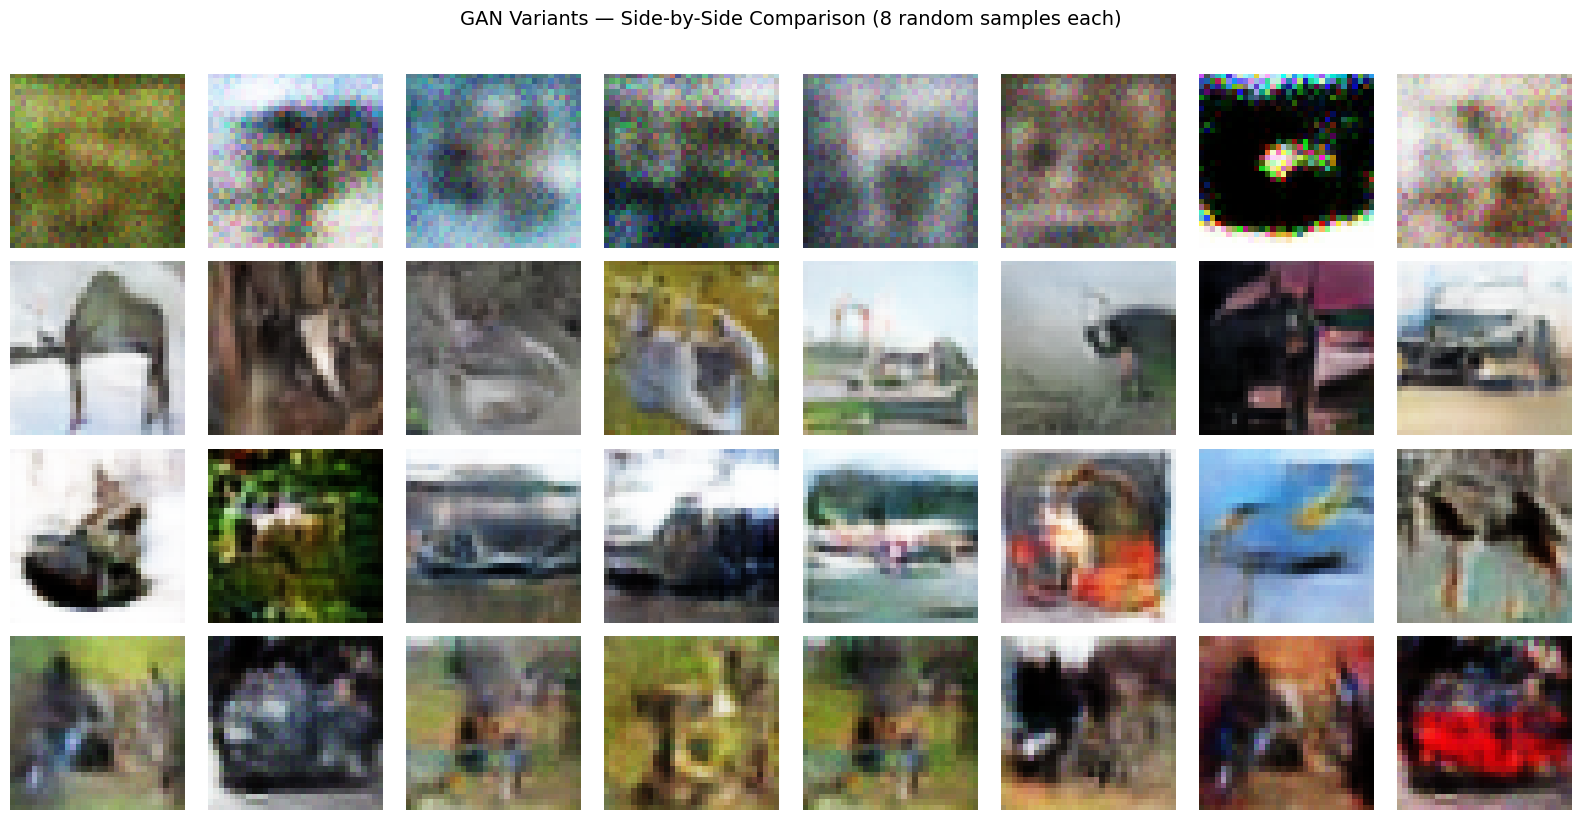

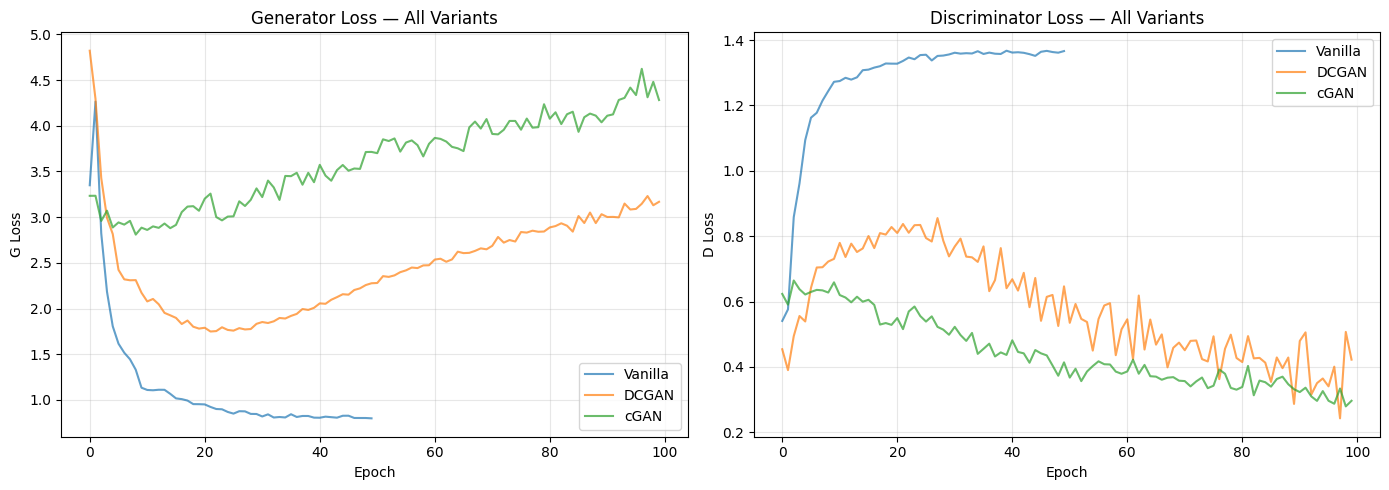


Note: WGAN-GP uses different loss scale (Wasserstein), plotted separately in Cell 4.


In [6]:
# Step 6: Evaluation & Comparison

"""
Compare all 4 GAN variants quantitatively (FID) and visually.
FID computed on 10K generated images vs 10K real test images.
"""

print("=" * 60)
print("[6/8] EVALUATION & COMPARISON")
print("=" * 60)

# FID for each variant
# Generate 10K images per variant for FID computation

def generate_images(generator, n_images, device, conditional=False, n_classes=10):
    # Generate n_images from a trained generator in batches.
    generator.eval()
    all_images = []
    batch = 256
    with torch.no_grad():
        for i in range(0, n_images, batch):
            curr_batch = min(batch, n_images - i)
            noise = torch.randn(curr_batch, LATENT_DIM, 1, 1, device=device)
            if conditional:
                # Uniform class distribution
                labels = torch.randint(0, n_classes, (curr_batch,), device=device)
                imgs = generator(noise, labels)
            else:
                imgs = generator(noise)
            # Convert to channel-last numpy for FID
            imgs_np = imgs.cpu().numpy().transpose(0, 2, 3, 1)  # (N, H, W, 3)
            all_images.append(imgs_np)
    generator.train()
    return np.concatenate(all_images, axis=0)

# Real test images (already channel-last from preprocessing)
real_test = X_test[:10000]

print("\nGenerating 10K images per variant for FID...")

print("\n1/4: Vanilla GAN...")
fake_vanilla = generate_images(G_vanilla, 10000, device)

print("2/4: DCGAN...")
fake_dcgan = generate_images(G_dc, 10000, device)

print("3/4: WGAN-GP...")
fake_wgan = generate_images(G_wgan, 10000, device)

print("4/4: Conditional GAN...")
fake_cgan = generate_images(G_cgan, 10000, device, conditional=True)

# Compute FID
print("\n" + "=" * 60)
print("Computing FID scores (InceptionV3 features)...")
print("=" * 60)

fid_vanilla = compute_fid(real_test, fake_vanilla, batch_size=100, device=str(device))
print(f"  Vanilla GAN FID: {fid_vanilla:.2f}")

fid_dcgan = compute_fid(real_test, fake_dcgan, batch_size=100, device=str(device))
print(f"  DCGAN FID:       {fid_dcgan:.2f}")

fid_wgan = compute_fid(real_test, fake_wgan, batch_size=100, device=str(device))
print(f"  WGAN-GP FID:     {fid_wgan:.2f}")

fid_cgan = compute_fid(real_test, fake_cgan, batch_size=100, device=str(device))
print(f"  cGAN FID:        {fid_cgan:.2f}")

# Comparison Table
print("\n" + "=" * 60)
print("CROSS-VARIANT COMPARISON")
print("=" * 60)
print(f"{'Variant':<20} {'FID':>10} {'G Params':>12} {'Training':>12}")
print("-" * 56)

variants = [
    ('Vanilla GAN', fid_vanilla, sum(p.numel() for p in G_vanilla.parameters()), 'BCE, 50ep'),
    ('DCGAN', fid_dcgan, sum(p.numel() for p in G_dc.parameters()), 'BCE, 100ep'),
    ('WGAN-GP', fid_wgan, sum(p.numel() for p in G_wgan.parameters()), 'Wass, 100ep'),
    ('Conditional GAN', fid_cgan, sum(p.numel() for p in G_cgan.parameters()), 'BCE, 100ep'),
]

for name, fid, params, training in variants:
    print(f"{name:<20} {fid:>10.2f} {params:>12,} {training:>12}")

best_variant = min(variants, key=lambda x: x[1])
print(f"\nBest FID: {best_variant[0]} ({best_variant[1]:.2f})")

# Side-by-side Visual Comparison
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
titles = ['Vanilla GAN', 'DCGAN', 'WGAN-GP', 'Conditional GAN']
sample_sets = [fake_vanilla[:8], fake_dcgan[:8], fake_wgan[:8], fake_cgan[:8]]

for row, (title, samples) in enumerate(zip(titles, sample_sets)):
    for col in range(8):
        img = samples[col]
        # Rescale [-1,1] -> [0,1]
        img = (img + 1.0) / 2.0
        img = np.clip(img, 0, 1)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(title, fontsize=11, rotation=0, labelpad=90, va='center')

fig.suptitle('GAN Variants — Side-by-Side Comparison (8 random samples each)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('results/variant_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Training Curves Overlay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# G losses
axes[0].plot(g_losses_vanilla, label='Vanilla', alpha=0.7)
axes[0].plot(g_losses_dc, label='DCGAN', alpha=0.7)
axes[0].plot(g_losses_cgan, label='cGAN', alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('G Loss')
axes[0].set_title('Generator Loss — All Variants')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# D losses
axes[1].plot(d_losses_vanilla, label='Vanilla', alpha=0.7)
axes[1].plot(d_losses_dc, label='DCGAN', alpha=0.7)
axes[1].plot(d_losses_cgan, label='cGAN', alpha=0.7)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('D Loss')
axes[1].set_title('Discriminator Loss — All Variants')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/all_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nNote: WGAN-GP uses different loss scale (Wasserstein), plotted separately in Cell 4.")

In [7]:
# Step 7: Performance Benchmarks

"""
Benchmark the best variant (DCGAN) for cross-framework comparison.
Track training performance, generator inference speed, and model size.
"""

print("=" * 60)
print("[7/8] PERFORMANCE BENCHMARKS")
print("=" * 60)

# Training Time (re-train DCGAN for timing)
# Train a fresh DCGAN for 10 epochs to get representative per-epoch timing
print("\nBenchmarking DCGAN training time (10 epochs)...")

G_bench = DCGenerator().to(device)
D_bench = DCDiscriminator().to(device)
G_bench.apply(weights_init)
D_bench.apply(weights_init)

opt_G_bench = optim.Adam(G_bench.parameters(), lr=LR, betas=BETAS)
opt_D_bench = optim.Adam(D_bench.parameters(), lr=LR, betas=BETAS)

BENCH_EPOCHS = 10

with track_performance(gpu=True) as perf:
    for epoch in range(BENCH_EPOCHS):
        for real_imgs, _ in train_loader:
            batch_size = real_imgs.size(0)
            real_imgs = real_imgs.to(device)

            # D step
            labels_real = torch.full((batch_size, 1), real_label, device=device)
            output_real = D_bench(real_imgs)
            loss_real = criterion(output_real, labels_real)

            noise = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
            fake_imgs = G_bench(noise).detach()
            labels_fake = torch.full((batch_size, 1), fake_label, device=device)
            output_fake = D_bench(fake_imgs)
            loss_fake = criterion(output_fake, labels_fake)

            loss_D = loss_real + loss_fake
            opt_D_bench.zero_grad()
            loss_D.backward()
            opt_D_bench.step()

            # G step
            noise = torch.randn(batch_size, LATENT_DIM, 1, 1, device=device)
            fake_imgs = G_bench(noise)
            output = D_bench(fake_imgs)
            loss_G = criterion(output, labels_real)

            opt_G_bench.zero_grad()
            loss_G.backward()
            opt_G_bench.step()

    torch.cuda.synchronize()

total_time = perf['time']
per_epoch_time = total_time / BENCH_EPOCHS
estimated_100ep = per_epoch_time * 100

print(f"  {BENCH_EPOCHS} epochs: {total_time:.2f}s ({per_epoch_time:.2f}s/epoch)")
print(f"  Estimated 100 epochs: {estimated_100ep:.1f}s ({estimated_100ep/60:.1f} min)")
print(f"  GPU memory peak: {perf['gpu_memory']:.0f} MB")

# Generator Inference Speed
print("\nBenchmarking generator inference speed...")

G_dc.eval()

def generate_batch(X_dummy):
    # Predict function for track_inference — X_dummy provides batch size.
    n = len(X_dummy)
    noise = torch.randn(n, LATENT_DIM, 1, 1, device=device)
    with torch.no_grad():
        output = G_dc(noise)
    torch.cuda.synchronize()
    return output.cpu().numpy()

# Use dummy input to set batch size for track_inference
X_dummy = np.zeros((100, 3, 32, 32), dtype=np.float32)
inference_stats = track_inference(generate_batch, X_dummy, n_runs=100)

print(f"  Per-sample: {inference_stats['per_sample_us']:.2f} µs")
print(f"  Throughput: {inference_stats['samples_per_sec']:,.0f} samples/sec")

G_dc.train()

# Model Size
print("\nModel sizes:")
g_size = get_model_size(G_dc, framework='pytorch')
d_size = get_model_size(D_dc, framework='pytorch')
print(f"  Generator:     {g_size / 1024:.1f} KB ({sum(p.numel() for p in G_dc.parameters()):,} params)")
print(f"  Discriminator: {d_size / 1024:.1f} KB ({sum(p.numel() for p in D_dc.parameters()):,} params)")
print(f"  Total:         {(g_size + d_size) / 1024:.1f} KB")
print(f"  Deploy size:   {g_size / 1024:.1f} KB (generator only)")

# ummary
print("\n" + "=" * 60)
print("BENCHMARK SUMMARY (DCGAN — Best Variant)")
print("=" * 60)
print(f"  FID:              {fid_dcgan:.2f}")
print(f"  Training time:    {estimated_100ep:.1f}s (100 epochs)")
print(f"  Per-epoch time:   {per_epoch_time:.2f}s")
print(f"  Inference speed:  {inference_stats['per_sample_us']:.2f} µs/sample")
print(f"  GPU memory peak:  {perf['gpu_memory']:.0f} MB")
print(f"  Generator size:   {g_size / 1024:.1f} KB")

[7/8] PERFORMANCE BENCHMARKS

Benchmarking DCGAN training time (10 epochs)...
  10 epochs: 31.92s (3.19s/epoch)
  Estimated 100 epochs: 319.2s (5.3 min)
  GPU memory peak: 345 MB

Benchmarking generator inference speed...
  Per-sample: 6.01 µs
  Throughput: 166,455 samples/sec

Model sizes:
  Generator:     4175.5 KB (1,068,928 params)
  Discriminator: 2591.0 KB (663,296 params)
  Total:         6766.5 KB
  Deploy size:   4175.5 KB (generator only)

BENCHMARK SUMMARY (DCGAN — Best Variant)
  FID:              30.57
  Training time:    319.2s (100 epochs)
  Per-epoch time:   3.19s
  Inference speed:  6.01 µs/sample
  GPU memory peak:  345 MB
  Generator size:   4175.5 KB


In [10]:
# Step 8: Save Results

"""
Save DCGAN results for cross-framework comparison.
Also save model weights for deployment staging.
"""

print("=" * 60)
print("[8/8] SAVE RESULTS")
print("=" * 60)

# Save model weights
torch.save(G_dc.state_dict(), 'results/dcgan_generator.pth')
torch.save(D_dc.state_dict(), 'results/dcgan_discriminator.pth')
print(f"Models saved: results/dcgan_generator.pth, dcgan_discriminator.pth")

# Build results dict (manual — generative models have no evaluate_classifier output)
results = {
    'framework': 'PyTorch',
    'model': 'DCGAN',
    'fid_score': float(fid_dcgan),
    'training_time': float(estimated_100ep),
    'per_epoch_time': float(per_epoch_time),
    'inference_time_per_sample_us': float(inference_stats['per_sample_us']),
    'model_size_bytes': int(g_size),
    'peak_memory_mb': float(perf['gpu_memory']),
    'n_params_generator': int(sum(p.numel() for p in G_dc.parameters())),
    'n_params_discriminator': int(sum(p.numel() for p in D_dc.parameters())),
    'epochs': DCGAN_EPOCHS,
    'latent_dim': LATENT_DIM,
    'batch_size': BATCH_SIZE,
    'learning_rate': LR,
    'all_fid_scores': {
        'vanilla_gan': float(fid_vanilla),
        'dcgan': float(fid_dcgan),
        'wgan_gp': float(fid_wgan),
        'conditional_gan': float(fid_cgan)
    }
}

# Save to local results/
save_results(results, save_dir='results')

# Save to shared cross-framework comparison
add_result('gans', results)

# Print cross-framework comparison table
print_comparison('gans')

[8/8] SAVE RESULTS
Models saved: results/dcgan_generator.pth, dcgan_discriminator.pth
    Results saved to: results\metrics.json
    Added 'PyTorch' to C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\results\gans.json
    Frameworks: 1 recorded

CROSS-FRAMEWORK COMPARISON: GANS
Metric                                                                                                                                                       PyTorch
--------------------------------------------------------------------------------------------------------------------------------------------------------------------
model                                                                                                                                                          DCGAN
fid_score                                                                                                                                                    30.5651
training_time                       